# Adaptive MLP for CKD Detection

This notebook trains an adaptive Multi-Layer Perceptron on the processed CKD dataset.

## Objectives

- Load the pre-split, leakage-free train/test CKD data (output of `preprocessing.ipynb`)
- Scale features using statistics fit on the training set only
- Train an MLP incrementally on growing batches of training data
- Adapt network capacity (hidden layer size) when F1 score stops improving
- Evaluate the best adaptive model and save results/figures

Output:

- `results/week6/ckd_adaptive_mlp_result.csv`
- `results/week6/ckd_adaptive_mlp_confusion_matrix.png`

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Only silence the specific noisy warning we've inspected and accepted
# (MLPClassifier occasionally not fully converging within max_iter on
# small batches) rather than suppressing every warning class.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

os.makedirs("../../results/week6", exist_ok=True)

## Load Pre-Split Data

In [2]:
# preprocessing.ipynb now splits BEFORE imputing/encoding, so these two
# files are already leakage-free — no re-splitting here, and no imputer
# or encoder in this notebook ever sees the test set.

train_df = pd.read_csv("../../data/processed/chronic_kidney_disease_train.csv")
test_df = pd.read_csv("../../data/processed/chronic_kidney_disease_test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

X_train = train_df.drop("class", axis=1)
y_train = train_df["class"].reset_index(drop=True)

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"].reset_index(drop=True)

print("\nTrain class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Train shape: (320, 25)
Test shape : (80, 25)

Train class balance:
class
1    200
0    120
Name: count, dtype: int64

Test class balance:
class
1    50
0    30
Name: count, dtype: int64


## Scaling

Fit on the training set only, then applied to test — consistent with how the split itself
was handled upstream in `preprocessing.ipynb`.

In [3]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:

from sklearn.model_selection import train_test_split

X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

## Adaptive Training

The model starts with 64 hidden neurons and trains on growing batches of the training set
(64 samples at a time). Whenever a batch fails to improve F1 over the current best, the
hidden layer grows by 32 neurons for the next batch — this is the "adaptive" behaviour.

In [5]:
batch_size = 64
hidden_layer = (64,)

best_f1 = 0
best_model = None

results = []

for end in range(batch_size, len(X_train_fit) + 1, batch_size):

    X_batch = X_train_fit[:end]
    y_batch = y_train_fit[:end]

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_batch, y_batch)

    # ------------------------
    # Validation Evaluation
    # ------------------------

    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]

    val_acc = accuracy_score(y_val, val_pred)
    val_prec = precision_score(y_val, val_pred, zero_division=0)
    val_rec = recall_score(y_val, val_pred, zero_division=0)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    val_roc = roc_auc_score(y_val, val_prob)

    results.append([
        end,
        hidden_layer[0],
        val_acc,
        val_prec,
        val_rec,
        val_f1,
        val_roc
    ])

    print("=" * 60)
    print(f"Training Samples : {end}")
    print(f"Hidden Neurons   : {hidden_layer[0]}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Validation Precision: {val_prec:.4f}")
    print(f"Validation Recall   : {val_rec:.4f}")
    print(f"Validation F1       : {val_f1:.4f}")
    print(f"Validation ROC AUC  : {val_roc:.4f}")

    # ------------------------
    # Adaptation
    # ------------------------

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model = model
    else:
        hidden_layer = (hidden_layer[0] + 32,)
        print("Adaptive Update")
        print("Increasing hidden neurons to", hidden_layer[0])

Training Samples : 64
Hidden Neurons   : 64
Validation Accuracy : 0.9531
Validation Precision: 1.0000
Validation Recall   : 0.9250
Validation F1       : 0.9610
Validation ROC AUC  : 1.0000
Training Samples : 128
Hidden Neurons   : 64
Validation Accuracy : 0.9375
Validation Precision: 1.0000
Validation Recall   : 0.9000
Validation F1       : 0.9474
Validation ROC AUC  : 1.0000
Adaptive Update
Increasing hidden neurons to 96
Training Samples : 192
Hidden Neurons   : 96
Validation Accuracy : 0.9844
Validation Precision: 1.0000
Validation Recall   : 0.9750
Validation F1       : 0.9873
Validation ROC AUC  : 1.0000
Training Samples : 256
Hidden Neurons   : 96
Validation Accuracy : 1.0000
Validation Precision: 1.0000
Validation Recall   : 1.0000
Validation F1       : 1.0000
Validation ROC AUC  : 1.0000


### Final batch

If the training set size isn't an exact multiple of `batch_size`, the remaining samples
are never used above — this final step trains once more on the **full** training set at
the last adapted hidden-layer size, so no data is left out of training.

In [6]:
if len(X_train_fit) % batch_size != 0:

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_fit, y_train_fit)

    # ------------------------
    # Validation Evaluation
    # ------------------------

    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]

    val_acc = accuracy_score(y_val, val_pred)
    val_prec = precision_score(y_val, val_pred, zero_division=0)
    val_rec = recall_score(y_val, val_pred, zero_division=0)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    val_roc = roc_auc_score(y_val, val_prob)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model = model

        print(
            "Final full-batch model is the new best "
            f"(Validation F1 = {val_f1:.4f})"
        )

## Final Evaluation

In [7]:
print("=" * 60)
print("BEST ADAPTIVE MODEL")
print("=" * 60)

pred = best_model.predict(X_test)
prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, zero_division=0)
recall = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)
auc = roc_auc_score(y_test, prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", auc)

BEST ADAPTIVE MODEL
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


## Error Analysis

In [8]:
analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

false_negatives = analysis[
    (analysis["Actual"] == 1) &
    (analysis["Predicted"] == 0)
]

false_positives = analysis[
    (analysis["Actual"] == 0) &
    (analysis["Predicted"] == 1)
]

print("False Negatives")
print(false_negatives)
print("\nTotal False Negatives:", len(false_negatives))

print("\nFalse Positives")
print(false_positives)
print("\nTotal False Positives:", len(false_positives))

False Negatives
Empty DataFrame
Columns: [Actual, Predicted]
Index: []

Total False Negatives: 0

False Positives
Empty DataFrame
Columns: [Actual, Predicted]
Index: []

Total False Positives: 0


## Save Results

In [9]:
adaptive_results = pd.DataFrame({
    "Model": ["Adaptive MLP"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "AUC": [auc]
})

adaptive_results.to_csv(
    "../../results/week6/ckd_adaptive_mlp_result.csv",
    index=False
)

print("Saved ../../results/week6/ckd_adaptive_mlp_result.csv")

adaptive_results

Saved ../../results/week6/ckd_adaptive_mlp_result.csv


,Model,Accuracy,Precision,Recall,F1,AUC
0,Adaptive MLP,1.0,1.0,1.0,1.0,1.0


## Confusion Matrix Figure

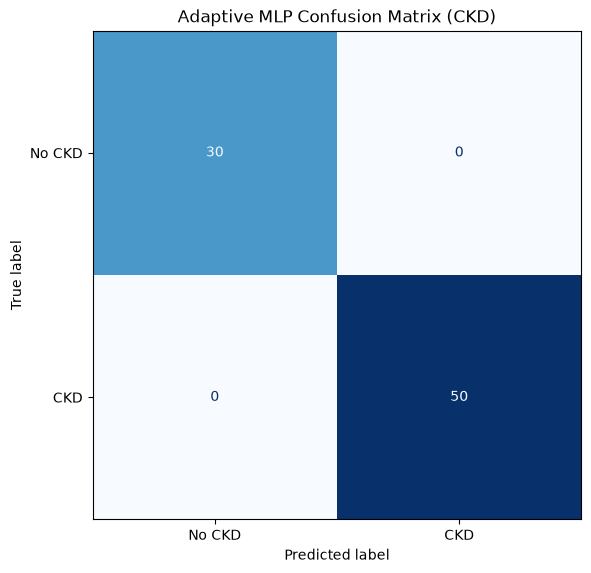

Confusion matrix saved to ../../results/week6/ckd_adaptive_mlp_confusion_matrix.png


In [10]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CKD", "CKD"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Adaptive MLP Confusion Matrix (CKD)")
plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_adaptive_mlp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to ../../results/week6/ckd_adaptive_mlp_confusion_matrix.png")

## Batch-by-Batch Progression

In [11]:
progress = pd.DataFrame(
    results,
    columns=["Training Samples", "Hidden Neurons", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
)

progress

,Training Samples,Hidden Neurons,Accuracy,Precision,Recall,F1,ROC AUC
0,64,64,0.953125,1.0,0.925,0.961039,1.0
1,128,64,0.937500,1.0,0.900,0.947368,1.0
2,192,96,0.984375,1.0,0.975,0.987342,1.0
3,256,96,1.000000,1.0,1.000,1.000000,1.0


In [12]:
print("=" * 50)
print("Adaptive MLP training completed successfully")
print("=" * 50)

Adaptive MLP training completed successfully
